---
# DNN : `MNIST` (avec `Keras`)
---

## Packages

In [11]:
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from keras import callbacks, layers, models
from keras.datasets import mnist    # import du jeu de données MNIST qui est déjà dans le package KERAS

---
## 1. Données
---

### 1.1. Importation

In [12]:
test_portion  = 1/5

# identification des échantillons train+validation et test
# dans tain_valid : on a les données qui vont servir à la constrution du modèle (seront sépar en ech d'apprentissage et de validation)
(X_train_valid, y_train_valid), (X_test, y_test) = mnist.load_data()

X_train, X_valid, y_train, y_valid = train_test_split(X_train_valid, y_train_valid, test_size=test_portion)

print('Dimensions de X_train :', X_train.shape)
print('Dimensions de X_valid :', X_valid.shape)
print('Dimensions de X_test  :', X_test.shape)

print('Dimensions de y_train :', y_train.shape)
print('Dimensions de y_valid :', y_valid.shape)
print('Dimensions de y_test  :', y_test.shape)

Dimensions de X_train : (48000, 28, 28)
Dimensions de X_valid : (12000, 28, 28)
Dimensions de X_test  : (10000, 28, 28)
Dimensions de y_train : (48000,)
Dimensions de y_valid : (12000,)
Dimensions de y_test  : (10000,)


### 1.2. Graphiques

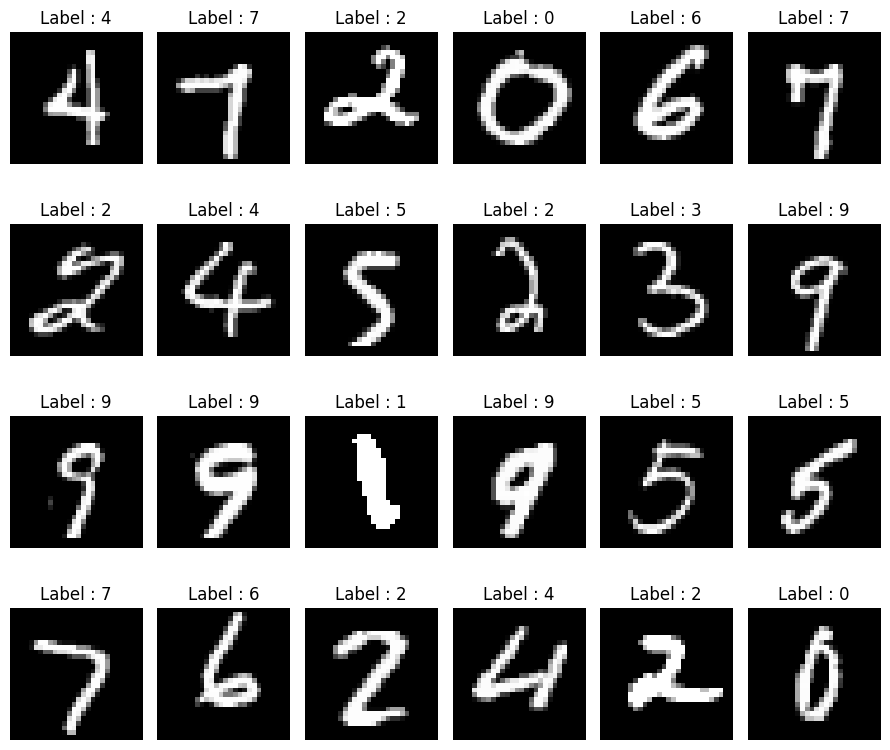

In [13]:
n_row = 4
n_col = 6
n = n_row * n_col

images = X_train[:n]
labels = y_train[:n]

fig, axes = plt.subplots(n_row, n_col, figsize=(1.5 * n_col, 2 * n_row))
for i in range(n):
    ax = axes[i//n_col, i%n_col]
    ax.imshow(images[i], cmap='gray')
    ax.set_title(f'Label : {labels[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

### 1.3. Normalisation

In [14]:
# pour les images on divise plutôt par le nb de pixel maximal plutôt que centrer - réduire
X_train_norm = X_train / 255
X_valid_norm = X_valid / 255
X_test_norm  = X_test  / 255

---
## 2. DNN
---

### 2.1. Architecture

In [15]:
dim_inputs  = (28, 28, 1)
dim_outputs = 10    # nb de nombres à prédire (0 à 9) = 10 neurones en sortie

n_units_hl1 = 100
n_units_hl2 = 100

dropout_hl1 = 0.2
dropout_hl2 = 0.2

model = models.Sequential(name='DNN')

model.add(layers.Input(shape=dim_inputs, name='Inputs'))

model.add(layers.Flatten(name='Flatten'))       # on vectorise la matrice 28 x 28 en un vecteur de 28x28 lignes et 1 colonne

model.add(layers.Dense(units=n_units_hl1, activation='relu', name='Hidden_layer_1'))
model.add(layers.Dropout(rate=dropout_hl1, name='Dropout_Hidden_layer_1'))

model.add(layers.Dense(units=n_units_hl2, activation='relu', name='Hidden_layer_2'))
model.add(layers.Dropout(rate=dropout_hl2, name='Dropout_Hidden_layer_2'))

model.add(layers.Dense(units=dim_outputs, activation='softmax', name='Output_layer'))     # fonction d'activation = softmax

model.summary()

Model: "DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_layer_1 (Dense)          │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Hidden_layer_1          │ (None, 100)            │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_layer_2 (Dense)          │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Hidden_layer_2          │ (None, 100)            │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_layer (Dense)            │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,610 (350.04 KB)

 Trainable params: 89,610 (350.04 KB)

 Non-trainable params: 0 (0.00 B)

### 2.2. Optimiseur

In [16]:
model.compile(optimizer = 'adam',
              loss      = 'sparse_categorical_crossentropy',    # 10 neurones en sortie avec valeur 1 ou 0 => on veut au final récupérer 1 valeur entre 0 et 9 => sparse_cat_crossentropy comprend que le Y de départ est stocké sous forme de scalaire t pas comme vecteur de 10 lignes
              metrics   = ['accuracy'])

callback = callbacks.EarlyStopping(monitor              = 'val_loss',
                                   mode                 = 'min',
                                   patience             = 5,
                                   restore_best_weights = True)

### 2.3. Entraînement

In [17]:
hist = model.fit(X_train_norm,
                 y_train,
                 batch_size      = 300,   # 300 images par batch
                 epochs          = 50,
                 validation_data = (X_valid_norm, y_valid),
                 callbacks       = [callback],
                 verbose         = 1)

Epoch 1/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7952 - loss: 0.6801 - val_accuracy: 0.9227 - val_loss: 0.2612
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9206 - loss: 0.2725 - val_accuracy: 0.9465 - val_loss: 0.1792
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9386 - loss: 0.2067 - val_accuracy: 0.9517 - val_loss: 0.1529
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9488 - loss: 0.1710 - val_accuracy: 0.9597 - val_loss: 0.1300
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9557 - loss: 0.1456 - val_accuracy: 0.9634 - val_loss: 0.1161
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9606 - loss: 0.1289 - val_accuracy: 0.9675 - val_loss: 0.1057
Epoch 7/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9657 - loss: 0.1150 - val_accuracy: 0.9688 - val_loss: 0.1006
Epoch 8/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9683 - loss: 0.1034 - val_accuracy: 0.

### 2.4. Prévisions

In [19]:
# donne les probas prédites sur ech test
y_test_pred = model.predict(X_test_norm)
y_test_pred[0:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[2.5327189e-08, 1.0532786e-07, 7.6337244e-07, 3.2627417e-05,
        8.4283781e-11, 2.1831445e-06, 2.9719569e-12, 9.9996281e-01,
        5.0339647e-08, 1.4476182e-06],
       [1.6023074e-08, 8.2691826e-05, 9.9991596e-01, 1.2593663e-06,
        6.0836541e-10, 3.8669651e-08, 1.7443746e-08, 2.2031235e-09,
        2.0190525e-09, 2.6136771e-15],
       [4.5348574e-07, 9.9980295e-01, 4.4262655e-05, 4.5518644e-07,
        1.9587504e-05, 1.2418907e-06, 2.2027276e-05, 6.8588626e-05,
        4.0288000e-05, 1.9376665e-07],
       [9.9998903e-01, 2.4827107e-09, 2.2472452e-06, 2.9769199e-08,
        1.6289727e-08, 5.8980163e-07, 3.2326861e-06, 3.5305726e-07,
        2.0357780e-09, 4.4771837e-06],
       [2.3642038e-08, 6.9217037e-08, 2.1512172e-07, 1.7846856e-09,
        9.9985540e-01, 1.4241978e-07, 5.1487427e-07, 4.0518685e-07,
        3.0238499e-07, 1.4297073e-04]], dtype=float32)

In [22]:
# le label prédit est celui correspondant à la proba la plus élevée
y_test_pred_classes = np.argmax(y_test_pred, axis=1)
y_test_pred_classes[0:5]

array([7, 2, 1, 0, 4])

In [23]:
# optionnel : on checke les Y initiaux
y_test[0:5]

array([7, 2, 1, 0, 4], dtype=uint8)

In [21]:
score_test = model.evaluate(X_test_norm, y_test, verbose=0)
print(f'Entropie test   : {score_test[0]:4.4f}')
print(f'Exactitude test : {score_test[1]:4.4f}')

Entropie test   : 0.0803
Exactitude test : 0.9784
